<a href="https://colab.research.google.com/github/BishalDas1010/Cab-ride-price-prediction/blob/main/Cab_ride_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("hello")

hello


Data fatch from Kaggle

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ravi72munde/uber-lyft-cab-prices")

print("Path to dataset files:", path)

100%|██████████| 73.5M/73.5M [00:00<00:00, 185MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4


In [3]:
import pandas as pd
import os

# List files in the downloaded directory
files_in_path = os.listdir(path)

# Filter for CSV files
csv_files = [f for f in files_in_path if f.endswith('.csv')]

# Assuming there's at least one CSV file and we want the first one
if csv_files:
    csv_file_name = csv_files[0]
    full_csv_path = os.path.join(path, csv_file_name)
    df = pd.read_csv(full_csv_path)
    print(f"Successfully loaded: {full_csv_path}")
else:
    print(f"No CSV files found in the directory: {path}")
    df = None # Or handle the error as appropriate

Successfully loaded: /root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4/cab_rides.csv


In [4]:
df.shape

(693071, 10)

In [5]:
df.columns.to_list()

['distance',
 'cab_type',
 'time_stamp',
 'destination',
 'source',
 'price',
 'surge_multiplier',
 'id',
 'product_id',
 'name']

In [6]:
df.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [7]:
#not missing  values
df.notna().sum().sort_values(ascending=False).head(20)

,0
distance,693071
cab_type,693071
time_stamp,693071
destination,693071
source,693071
surge_multiplier,693071
product_id,693071
id,693071
name,693071
price,637976


In [8]:
#missing values nan,None,Nan ->True

In [9]:
df.isna().sum().sort_values(ascending=True).head(20)

,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
surge_multiplier,0
id,0
product_id,0
name,0
price,55095


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630155 entries, 0 to 693070
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   distance          630155 non-null  float64       
 1   cab_type          630155 non-null  object        
 2   time_stamp        630155 non-null  float64       
 3   destination       630155 non-null  object        
 4   source            630155 non-null  object        
 5   price             630155 non-null  float64       
 6   surge_multiplier  630155 non-null  float64       
 7   id                630155 non-null  object        
 8   product_id        630155 non-null  object        
 9   name              630155 non-null  object        
 10  datetime          630155 non-null  datetime64[ns]
 11  hour              630155 non-null  float64       
 12  haversine_km      630155 non-null  float64       
 13  day_of_week       630155 non-null  int32         
 14  is_weeken

# Describe Function

## 🔹 Definitions
- **Mean → Average value**
- **Standard Deviation (std) → tells whether data is close to the average or spread far from it**

---

## Formula

### Mean
$$
\text{Mean} = \frac{\sum x}{n}
$$

### Standard Deviation (concept)
$$
\text{Std measures how much values deviate from the mean}
$$

---

##  Example 1 (Low Std)

**Data:**
```python
[10, 11, 12]

In [10]:
df.describe(include='all')

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
count,693071.000000,693071,6.930710e+05,693071,693071,637976.000000,693071.000000,693071,693071,693071
unique,NaN,2,NaN,12,12,NaN,NaN,693071,13,13
top,NaN,Uber,NaN,Financial District,Financial District,NaN,NaN,e7fdc087-fe86-40a5-a3c3-3b2a8badcbda,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL
freq,NaN,385663,NaN,58851,58857,NaN,NaN,1,55096,55096
mean,2.189430,NaN,1.544046e+12,NaN,NaN,16.545125,1.013870,NaN,NaN,NaN
std,1.138937,NaN,6.891925e+08,NaN,NaN,9.324359,0.091641,NaN,NaN,NaN
min,0.020000,NaN,1.543204e+12,NaN,NaN,2.500000,1.000000,NaN,NaN,NaN
25%,1.280000,NaN,1.543444e+12,NaN,NaN,9.000000,1.000000,NaN,NaN,NaN
50%,2.160000,NaN,1.543737e+12,NaN,NaN,13.500000,1.000000,NaN,NaN,NaN
75%,2.920000,NaN,1.544828e+12,NaN,NaN,22.500000,1.000000,NaN,NaN,NaN


# EDA (visual + nnumeric )

In [11]:
df['datetime'] =pd.to_datetime( df['time_stamp'],unit="ms")

In [12]:
df["hour"] = df["datetime"].dt.hour

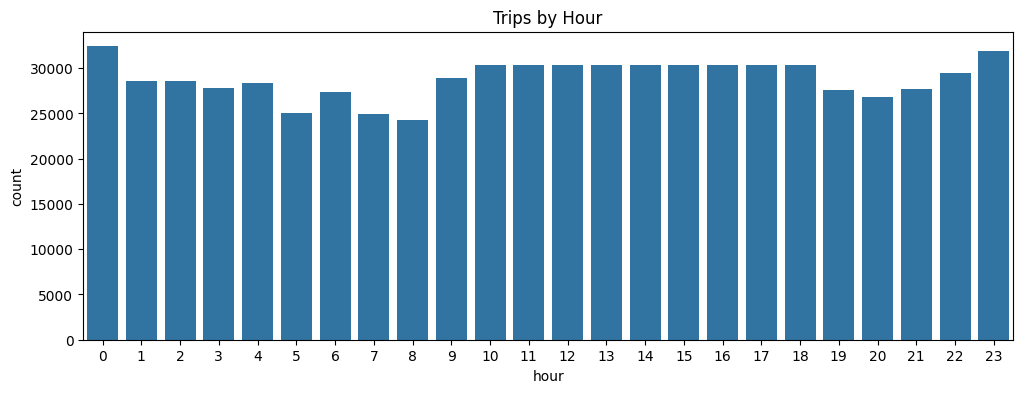

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))
sns.countplot(x=df["hour"])
plt.title("Trips by Hour")
plt.show()

distance vs price



In [14]:
print("Your dataset has no lat/lon → using provided 'distance' as haversine_km.")
df["haversine_km"] = df["distance"]

Your dataset has no lat/lon → using provided 'distance' as haversine_km.


## Preprocessing & Feature Engineering

In [15]:
print("CLEAN OUTLIERS")
df = df[df["haversine_km"]< df["haversine_km"].quantile(0.995)]
df = df[df["price"]<df ["price"].quantile(0.995)]


''' I removed the top 0.5% of the largest values in both distance (haversine_km) and price.
Very long trips or extremely expensive rides are outliers that can skew the model,
so dropping them makes predictions more accurate.''

CLEAN OUTLIERS


#IMPUTE NUMERIC



In [17]:
import numpy as np

print("Inputing Missing Neumaric values ")
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols

Inputing Missing Neumaric values 


Index(['distance', 'time_stamp', 'price', 'surge_multiplier', 'hour',
       'haversine_km'],
      dtype='object')

### That line of code is filling in missing
 numeric values in your DataFrame using the median


In [20]:
from sklearn.impute import SimpleImputer
# Replace missing values with median
df[num_cols] = SimpleImputer(strategy="median").fit_transform(df[num_cols])

# SimpleImputer(strategy="median") → makes an object that fills missing values with the median.

# .fit_transform(df[num_cols]) →

# fit: finds the median for each numeric column

# transform: replaces missing values with those medians

## Feature Engineering

In [23]:
print("Creating Time Feature....")
# Extract day of week (monday =0, 6= Sunday)
df ["day_of_week"] = df['datetime'].dt.day_of_week
# Weekend indicator
df["is_weekend"] =df["day_of_week"].isin([5,6]).astype(int) # 5 ,6 cuz Weekend
#Rush hour indicator
df["is_rush_hour"] = df["hour"].isin([7,8,9,16,17,18,19]).astype(int)

Creating Time Feature....


In [26]:
df['is_rush_hour']

,is_rush_hour
0,1
1,0
2,0
3,0
4,0
...,...
693065,0
693066,0
693067,0
693069,0


#### day_of_week: Extracted the day of the week from the datetime.
#### is_weekend: Created a binary column that is 1 if the ride is on Saturday or Sunday,otherwise 0.
#### is_rush_hour : Created a binary column that is 1 if the ride occurs during typical morning or evening rush hours (7-9 AM and 4-6 PM), otherwise 0.

In [22]:
df.head(1)

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,datetime,hour,haversine_km,day_of_week,is_weekend,is_rush_hour
0,0.44,Lyft,1.544953e+12,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,2018-12-16 09:30:07.890,9.0,0.44,6,1,1


## DISTANCE BUCKETS



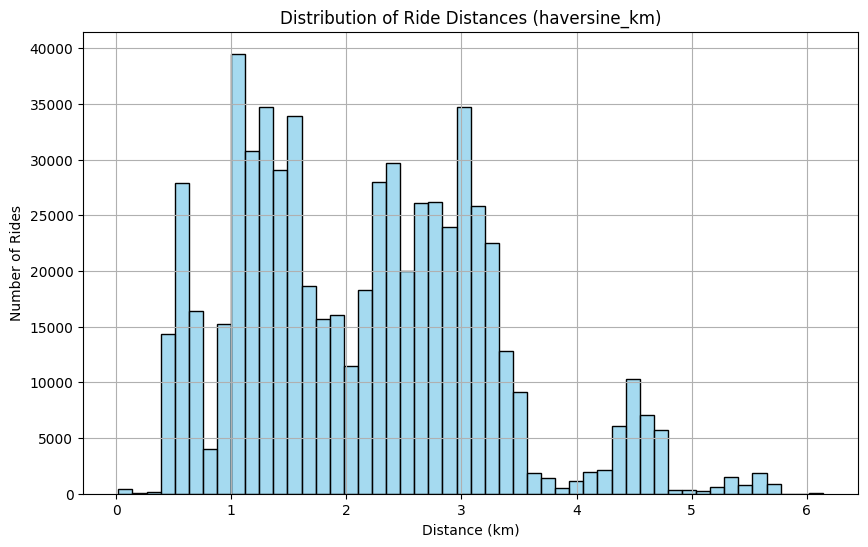

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram of ride distances
plt.figure(figsize=(10,6))
sns.histplot(df["haversine_km"], bins=50, kde=False, color="skyblue")

plt.title("Distribution of Ride Distances (haversine_km)")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Rides")
plt.grid(True)
plt.show()


In [29]:
import numpy as np
bins = [0, 0.5, 2, 5, 10, 20, 50, np.inf]
#the labels are just friendly names for the distance ranges you defined, so
# you can easily interpret and work with the categories.
labels = ["<0.5","0.5-2","2-5","5-10","10-20","20-50","50+"]
# Assign each ride to a distance bucket
df["dist_bucket"] = pd.cut(df["haversine_km"], bins=bins, labels=labels)

In [32]:
from sklearn.preprocessing import LabelEncoder
### ENCODING ###
print("Encoading categorical Variables ---")
for col in ["cab_type","product_id","source","destination","dist_bucket"]:
  df[col] =LabelEncoder().fit_transform(df[col].astype(str))
  print("Feature Eng done")

Encoading categorical Variables ---
Feature Eng done
Feature Eng done
Feature Eng done
Feature Eng done
Feature Eng done


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630155 entries, 0 to 693070
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   distance          630155 non-null  float64       
 1   cab_type          630155 non-null  int64         
 2   time_stamp        630155 non-null  float64       
 3   destination       630155 non-null  int64         
 4   source            630155 non-null  int64         
 5   price             630155 non-null  float64       
 6   surge_multiplier  630155 non-null  float64       
 7   id                630155 non-null  object        
 8   product_id        630155 non-null  int64         
 9   name              630155 non-null  object        
 10  datetime          630155 non-null  datetime64[ns]
 11  hour              630155 non-null  float64       
 12  haversine_km      630155 non-null  float64       
 13  day_of_week       630155 non-null  int32         
 14  is_weeken

## TRAIN TSET SPLIT

In [36]:
from sklearn.model_selection import train_test_split
import numpy as np
#Extract date from datetime
df["date"] = df["datetime"].dt.date
# Unique dates sorted
unique_dates = np.sort(df["date"].unique())
#Use last 20 persentage of dat
test_len = int(0.2 * len(unique_dates))
test_dates = unique_dates[-test_len:]
train_mask = df["date"].isin(unique_dates[:-test_len])
test_mask = df["date"].isin(test_dates)

# Separate features and target
X = df.drop(columns=["price", "time_stamp", "datetime", "date"], errors="ignore")
y = df["price"]

### BaseLine Liner Regression

In [ ]:
from sklearn.model_selection import LinerRegression
lr = LinerRegression()

